In [1]:
import numpy as np 
import pandas as pd 
import scanpy as sc
import scipy as sp

import phate
from sklearn.decomposition import PCA
import umap

import sys, pathlib
sys.path.insert(0, str(next(p for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents) if (p/"src").is_dir())))
from utils.benchmark_utils import visualization, run_models_from_adata, benchmark_from_adata, split_adata
from utils.simulation_utils import add_noise, dropout, split_and_transform_batch, clean_and_encode_labels, preprocess_adata, split_and_transform_batch_stratified, global_label_masking, ensure_label_intersection



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/cvmfs/ai.mila.quebec/apps/arch/distro/python/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/cvmfs/ai.mila.quebec/apps/arch/distro/python/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/mila/m/myriam.lizotte/envs/env_fosta_neurips/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/mila/m/myriam.lizotte/envs/env_fosta_neurips/lib/py

In [2]:
base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
mali_path = "/home/mila/m/myriam.lizotte/MALI"
scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"
batch = 4


In [3]:
# load a dataset
jobid="9367609"
save_path_subfolder = f"/home/mila/m/myriam.lizotte/scratch/RF-MALI/results/real_batches_immune/{jobid}/0_1"
path = f"{save_path_subfolder}/adata_intermediate.h5ad"
adata = sc.read_h5ad(path)

In [4]:
adata

AnnData object with n_obs × n_vars = 5851 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'final_annotation_masked', 'mask_indices', 'cell_type_cleaned_encoded'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca'
    obsm: 'FoSTA_PHATE_OOB', 'FoSTA_PHATE_denseOT', 'FoSTA_PHATE_t2', 'FoSTA_PHATE_tauto', 'Harmony', 'MALI', 'Scanorama', 'Unintegrated', 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [5]:
def batch_baseline_label_agnostic(X1, X2, seed=42, embedder = "PHATE", n_components=2, **kwargs):
    '''Method to optimize batch correction without any regard for bio preservation
    randomly assign each point of the smaller dataset to a point of the larger dataset, and copy its embedding.
    inputs: X1, X2: two datasets to be batch corrected. shape (n_samples1, n_features), (n_samples2, n_features)
    seed: random seed for reproducibility
    embedder: which dimensionality reduction method to use. one of "PHATE", "PCA", "UMAP"
    n_components: number of dimensions to reduce to
    kwargs: additional arguments to pass to the embedder
    output: emb: the embedding of the two datasets in the same space. shape (n_samples1 + n_samples2, n_components)
    '''

    # assume X2 is larger, if not, swap them
    if X1.shape[0] > X2.shape[0]: # if X1 larger
        X1, X2 = X2, X1
    
    emb2 = embed(X2, embedder = embedder, seed = seed, n_components = n_components, **kwargs) # embed X2
    rng = np.random.default_rng(seed=seed)
    emb1 = rng.choice(emb2, axis=0, size=X1.shape[0], replace=False)
    # for each point of X1, randomly assign it to a point of X2. embed it on top of that point.
    
    emb = np.vstack((emb1, emb2))
    
    return emb # return the embedding


def batch_baseline(X1, X2, y1, y2, seed=42, embedder = "PHATE", n_components=2, **kwargs):
    '''Method to optimize batch correction without any regard for bio preservation
    randomly assign each point of the smaller dataset to a point of the larger dataset *OF THE SAME LABEL*, and copy its embedding.
    inputs: X1, X2: two datasets to be batch corrected. shape (n_samples1, n_features), (n_samples2, n_features)
    y1, y2: labels for the two datasets
    seed: random seed for reproducibility
    embedder: which dimensionality reduction method to use. one of "PHATE", "PCA", "UMAP"
    n_components: number of dimensions to reduce to
    kwargs: additional arguments to pass to the embedder
    output: emb: the embedding of the two datasets in the same space. shape (n_samples1 + n_samples2, n_components)
    '''
    if type(X1) == sp.sparse.csr_matrix:
        X = sp.sparse.vstack([X1, X2]) # stack the two datasets together
    else:
        X = np.vstack([X1, X2]) # stack the two datasets together
    
    emb = embed(X, embedder = embedder, seed = seed, n_components = n_components, **kwargs) # embed both together
    
    rng = np.random.default_rng(seed=seed)
    
    for label in np.unique(y1): # for each label in y1
        idx1 = y1 == label
        idx2 = y2 == label
        idx1_full = np.concatenate([idx1, np.zeros_like(idx2)]) # create a full index for X1
        idx2_full = np.concatenate([np.zeros_like(idx1), idx2]) # create a full index for X2
     
     
        if idx1.sum() < idx2.sum(): # if there are more points of this label in X2 than in X1, replace embs of X1
            emb[idx1_full] = rng.choice(emb[idx2_full], axis=0, size=np.sum(idx1), replace=False)
            # for each point of X1 of label i, replace its embedding with a randomly chosen embedding of batch2 of label i. this way, we ensure that points of the same label are embedded together, regardless of batch.
        
        else: # if there are more points of this label in X1 than in X2, replace embs of X2
            emb[idx2_full] = rng.choice(emb[idx1_full], axis=0, size=np.sum(idx2), replace=False)
            # for each point of X2 of label i, replace its embedding with a randomly chosen embedding of batch1 of label i. this way, we ensure that points of the same label are embedded together, regardless of batch.
    
    return emb # return the embedding



def embed(X, embedder, n_components=2, seed=42, **kwargs):
    if embedder == "PHATE":
        phate_operator = phate.PHATE(n_components=n_components, random_state=seed, **kwargs)
        emb = phate_operator.fit_transform(X)
    elif embedder == "PCA":
        pca = PCA(n_components=n_components, random_state=seed)
        emb = pca.fit_transform(X)
    elif embedder == "UMAP":
        umap_operator = umap.UMAP(n_components=n_components, n_neighbors=5, min_dist=0.3, random_state=seed)
        emb = umap_operator.fit_transform(X)

    else:
        raise ValueError(f"Unknown embedder: {embedder}")
    
    return emb

In [6]:
def batch_baseline_from_adata(adata, batch_key, label_key, embedding_basis, seed=42, embedder = "PHATE", n_components=2, **kwargs):
    x0, x1, y0, y1, idxs_d = split_adata(adata, batch_key=batch_key, label_key=label_key, embedding_basis=embedding_basis)
    embedding = batch_baseline(x0, x1, y0, y1, seed=seed, embedder=embedder, n_components=n_components, **kwargs)
    
    # put embedding in adata (after reordering rows of the embedding to match adata.obs.index)
    emb = pd.DataFrame(embedding)
    emb = emb.set_index(idxs_d)  
    emb = emb.reindex(adata.obs.index)
    adata.obsm["batch_baseline"] = np.asarray(emb)
    return adata

def batch_baseline_label_agnostic_from_adata(adata, batch_key, label_key, embedding_basis, seed=42, embedder = "PHATE", n_components=2, **kwargs):
    x0, x1, y0, y1, idxs_d = split_adata(adata, batch_key=batch_key, label_key=label_key, embedding_basis=embedding_basis)
    embedding = batch_baseline_label_agnostic(x0, x1, seed=seed, embedder=embedder, n_components=n_components, **kwargs)

    # put embedding in adata (after reordering rows of the embedding to match adata.obs.index)
    emb = pd.DataFrame(embedding)
    emb = emb.set_index(idxs_d)  
    emb = emb.reindex(adata.obs.index)
    adata.obsm["batch_baseline"] = np.asarray(emb)
    return adata

In [7]:
adata = batch_baseline_from_adata(adata, batch_key="batch", label_key="final_annotation", embedding_basis="X_pca", seed=42, embedder="PHATE", n_components=2)

Calculating PHATE...
  Running PHATE on 5851 observations and 30 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...


    Calculated KNN search in 2.90 seconds.
    Calculating affinities...
    Calculated affinities in 1.40 seconds.
  Calculated graph and diffusion operator in 4.30 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.26 seconds.
    Calculating KMeans...
    Calculated KMeans in 5.15 seconds.
  Calculated landmark operator in 5.41 seconds.
  Calculating optimal t...
    Automatically selected t = 34
  Calculated optimal t in 3.05 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 2.27 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 2.82 seconds.
Calculated PHATE in 18.59 seconds.


In [24]:
# run other methods 

from utils.script_utils import main_argparser, prepare_adata, run_methods, evaluate_and_save_results, save_embeddings
from methods_configs_test import methods_params_dict

label_key = "final_annotation"
encoded_label_key = "cell_type_cleaned_encoded"
batch_key = "batch"
from types import SimpleNamespace
args = {"seed": 42, "components": 2}
args = SimpleNamespace(**args)


adata.layers["counts"] = adata.layers["counts"].astype(np.float32)
adata = run_methods(adata, save_path_subfolder, label_key, encoded_label_key=encoded_label_key, batch_key= batch_key, methods_params_dict=methods_params_dict, args=args)

Seed set to 42


Running method scVI...


/home/mila/m/myriam.lizotte/envs/env_fosta_neurips/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/mila/m/myriam.lizotte/envs/env_fosta_neurips/l ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/mila/m/myriam.lizotte/envs/env_fosta_neurips/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `s

Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

RuntimeError: Could not infer dtype of numpy.float32

In [23]:
for col in adata.obs.columns:
    if adata.obs[col].dtype == "object":
        adata.obs[col] = adata.obs[col].astype(str)
        
        
adata.obs[batch_key] = adata.obs[batch_key].astype("category")

In [9]:
methods = list(adata.obsm.keys())
methods.remove("X_pca")
methods.remove("Unintegrated")

batch_key = "batch"
original_label_key = "final_annotation"
df = benchmark_from_adata(adata, methods, batch_key = batch_key, label_key = original_label_key)

Computing neighbors:   0%|          | 0/10 [00:22<?, ?it/s]


KeyboardInterrupt: 

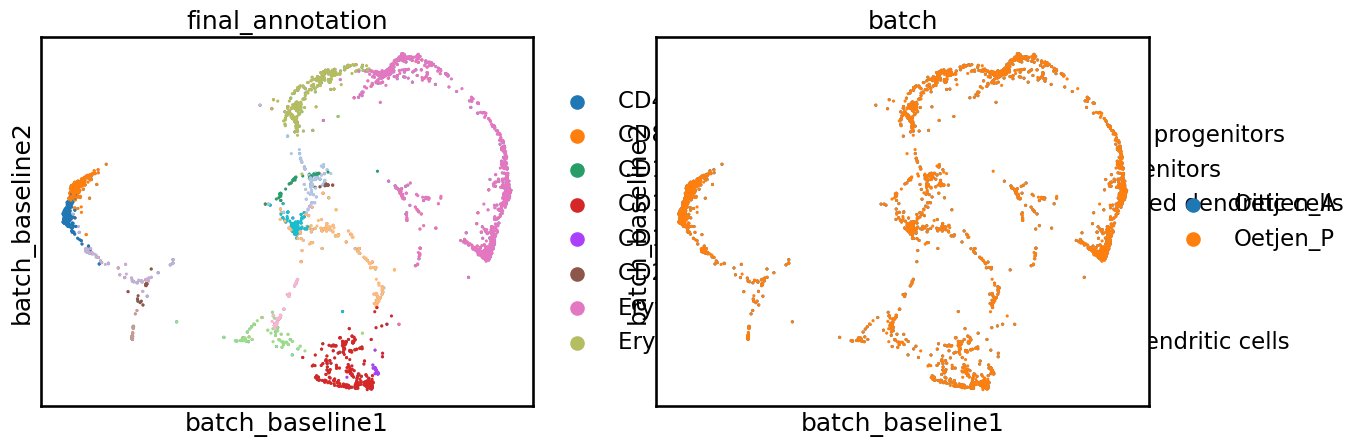

In [25]:
sc.pl.embedding(adata, basis="batch_baseline", color=["final_annotation", "batch"])

3265
o
2586
.


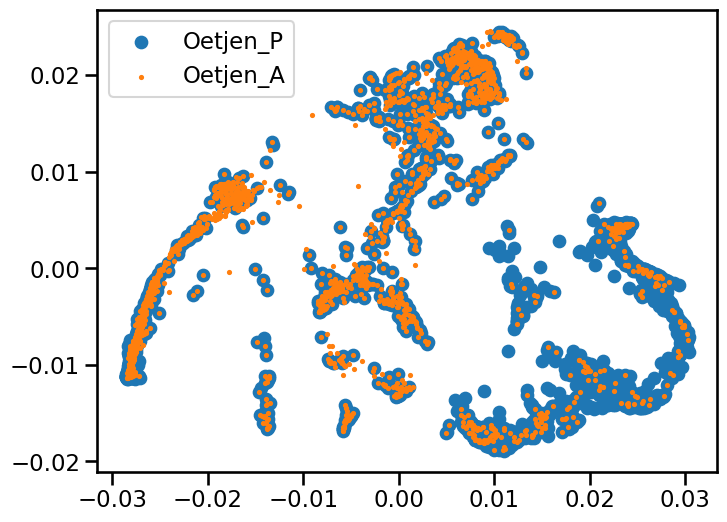

In [102]:
import matplotlib.pyplot as plt

markers = ["o", "."]
sizes = [70, 20]
batches = adata.obs["batch"].unique().tolist()
batches.reverse()
i=0
plt.figure(figsize=(8,6))
for batch in batches:
    idxs = adata.obs["batch"] == batch
    print(idxs.sum())
    print(markers[i])
    plt.scatter(adata.obsm["batch_baseline"][idxs, 0], adata.obsm["batch_baseline"][idxs, 1], label=batch, s=sizes[i], marker=markers[i])
    i += 1
plt.legend()
plt.show()

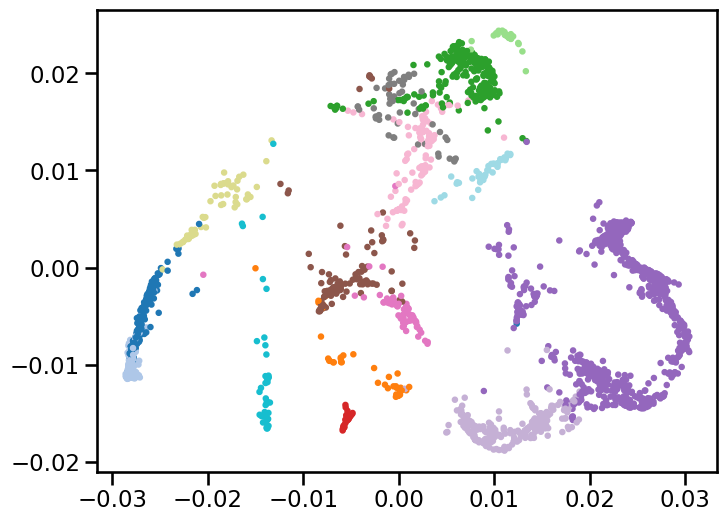

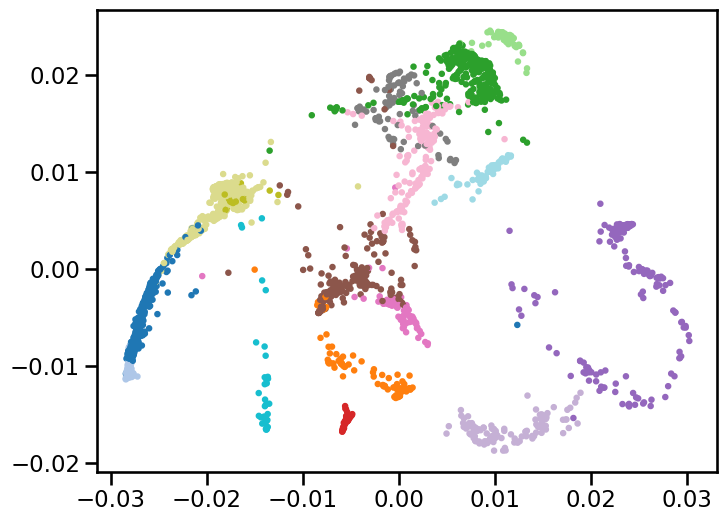

In [103]:

for batch in batches:
    plt.figure(figsize=(8,6))
    idxs = adata.obs["batch"] == batch
    labels = adata.obs["final_annotation"][idxs]
    plt.scatter(adata.obsm["batch_baseline"][idxs, 0], adata.obsm["batch_baseline"][idxs, 1], c=labels.astype("category").cat.codes, s=10, cmap="tab20")
    plt.show()
    # plt.legend()